<a href="https://colab.research.google.com/github/manavsharma111/Machine-Learning/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs # data set bana deta hai
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.6,random_state=42)

In [6]:
df = pd.DataFrame(X, columns=['Feature1','Feature2'])
X

array([[-6.1900632 , -7.30201545],
       [ 3.02174685,  1.94059276],
       [ 5.9537606 ,  1.48819071],
       [-2.74446251,  8.13617716],
       [ 5.36060719,  1.72832446],
       [ 5.13808033,  1.45951939],
       [-5.34357647, -6.93774553],
       [ 4.80215293,  1.94302682],
       [ 3.99930658,  1.88774199],
       [-7.25451834, -6.86445496],
       [ 4.25193511,  1.32424088],
       [-1.81404028,  8.52187674],
       [-1.2293776 ,  7.84303345],
       [-2.16666332,  9.69562551],
       [ 4.81374375,  3.21841016],
       [ 5.27493353,  0.91792599],
       [-2.5524037 ,  9.61640587],
       [-7.5532604 , -6.65066375],
       [-6.8302568 , -6.24082137],
       [-3.17299861,  8.29656215],
       [ 3.80073829,  2.31095123],
       [-2.38387947,  7.83848405],
       [ 4.98581301,  2.15991978],
       [-5.94031277, -6.91955975],
       [-7.14748736, -6.7636556 ],
       [ 4.87655012,  1.720579  ],
       [ 4.48689251,  2.87556548],
       [-6.4081471 , -6.62483506],
       [-6.71939703,

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled

array([[-9.69818350e-01, -1.33993820e+00],
       [ 9.63343617e-01,  8.22475346e-02],
       [ 1.57864695e+00,  1.26351772e-02],
       [-2.46735247e-01,  1.03557927e+00],
       [ 1.45416962e+00,  4.95852224e-02],
       [ 1.40747082e+00,  8.22344111e-03],
       [-7.92177264e-01, -1.28388698e+00],
       [ 1.33697413e+00,  8.26220693e-02],
       [ 1.16849128e+00,  7.41152400e-02],
       [-1.19320161e+00, -1.27260956e+00],
       [ 1.22150712e+00, -1.25922376e-02],
       [-5.14797137e-02,  1.09492794e+00],
       [ 7.12157877e-02,  9.90472440e-01],
       [-1.25480095e-01,  1.27553591e+00],
       [ 1.33940654e+00,  2.78868839e-01],
       [ 1.43619041e+00, -7.51130357e-02],
       [-2.06430378e-01,  1.26334617e+00],
       [-1.25589470e+00, -1.23971291e+00],
       [-1.10416740e+00, -1.17664933e+00],
       [-3.36666506e-01,  1.06025816e+00],
       [ 1.12682035e+00,  1.39235617e-01],
       [-1.71064404e-01,  9.89772412e-01],
       [ 1.37551647e+00,  1.15995990e-01],
       [-9.

In [9]:
inertia = []
K_range = range(1, 11)

In [10]:
for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

In [11]:
inertia

[1000.0000000000006,
 297.8954141051723,
 11.575484723104985,
 9.752067977356848,
 8.257175272446279,
 6.917577320416797,
 6.334755391595288,
 5.704177177901426,
 5.060234133532074,
 4.7623618981303935]

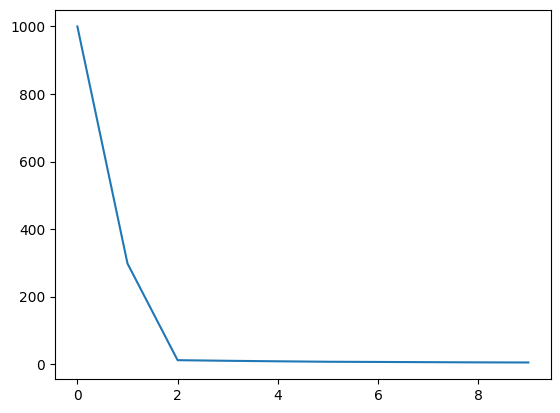

In [13]:
plt.plot(inertia)
plt.show()

In [20]:
kmeans_final = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [21]:
cluster_labels

array([1, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 2, 2, 2, 0, 0, 2, 1, 1, 2, 0, 2,
       0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2, 2,
       2, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 1,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2, 2, 1, 2, 1,
       1, 1, 1, 1, 1, 0, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 0,
       2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 0, 0, 0, 2, 1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 2, 2, 1, 1, 0, 1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0,
       0, 2, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 0,
       2, 2, 1, 1, 0, 2, 2, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 1, 2,
       0, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0,

In [22]:
df['cluster']=cluster_labels

<Axes: xlabel='Feature1', ylabel='Feature2'>

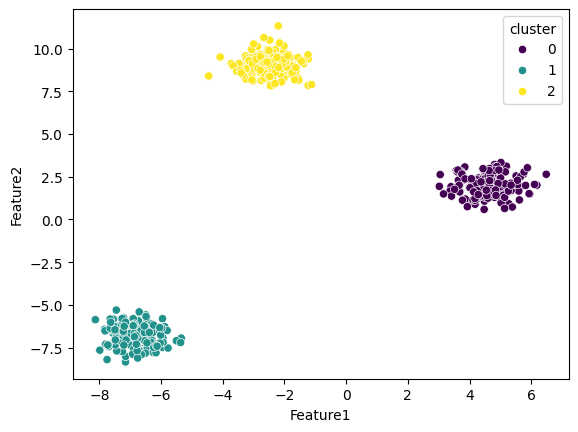

In [23]:
sns.scatterplot(x=df['Feature1'],
                y=df['Feature2'],
                hue=df['cluster'],
                palette='viridis')

In [24]:
from sklearn.datasets import make_moons

In [25]:
X, Y_true = make_moons(n_samples=500, noise=0.05, random_state=42)

In [26]:
from sklearn.cluster import KMeans, DBSCAN

In [27]:
df = pd.DataFrame(X, columns=['Feature1','Feature2'])
X

array([[ 0.83058575, -0.44773257],
       [ 0.70167816,  0.81691843],
       [ 1.02208004, -0.49257102],
       [-0.31676455,  0.95343844],
       [ 0.29322631,  1.05718523],
       [ 1.25490304, -0.48343549],
       [ 1.05385133, -0.44269047],
       [ 0.03137971,  1.05301203],
       [ 0.62054473,  0.71309598],
       [ 1.7876566 , -0.14295878],
       [ 0.99907493,  0.09180641],
       [-0.70723041,  0.57499903],
       [ 1.46479643, -0.47111862],
       [ 0.42712245,  0.83103216],
       [ 1.05341942, -0.50102941],
       [ 1.19597671, -0.49472393],
       [ 1.99422286,  0.42426007],
       [ 0.93175527,  0.39426183],
       [ 0.41104275, -0.33348189],
       [ 1.49073255, -0.38560138],
       [ 1.97517181,  0.35930615],
       [ 2.0470942 ,  0.41068552],
       [-0.00592133,  0.14862165],
       [ 0.82592072, -0.42998975],
       [ 0.54309448,  0.75144817],
       [ 1.8709548 ,  0.20141701],
       [ 1.9224317 ,  0.43263225],
       [-0.86765136,  0.45505598],
       [ 0.28216036,

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled

array([[ 3.75124610e-01, -1.40367864e+00],
       [ 2.26814579e-01,  1.13562771e+00],
       [ 5.95441542e-01, -1.49371022e+00],
       [-9.44918355e-01,  1.40974769e+00],
       [-2.43115122e-01,  1.61806199e+00],
       [ 8.63307743e-01, -1.47536691e+00],
       [ 6.31994868e-01, -1.39355455e+00],
       [-5.44373389e-01,  1.60968258e+00],
       [ 1.33469407e-01,  9.27161489e-01],
       [ 1.47624835e+00, -7.91720052e-01],
       [ 5.68973828e-01, -3.20332517e-01],
       [-1.39415493e+00,  6.49875138e-01],
       [ 1.10479310e+00, -1.45063573e+00],
       [-8.90656986e-02,  1.16396681e+00],
       [ 6.31497948e-01, -1.51069392e+00],
       [ 7.95512152e-01, -1.49803307e+00],
       [ 1.71390580e+00,  3.47204752e-01],
       [ 4.91521597e-01,  2.86970964e-01],
       [-1.07565622e-01, -1.17427347e+00],
       [ 1.13463298e+00, -1.27892474e+00],
       [ 1.69198729e+00,  2.16783084e-01],
       [ 1.77473503e+00,  3.19948276e-01],
       [-5.87288774e-01, -2.06252585e-01],
       [ 3.

In [30]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [31]:
df['kmeans_cluster'] = kmeans_labels

<Axes: xlabel='Feature1', ylabel='Feature2'>

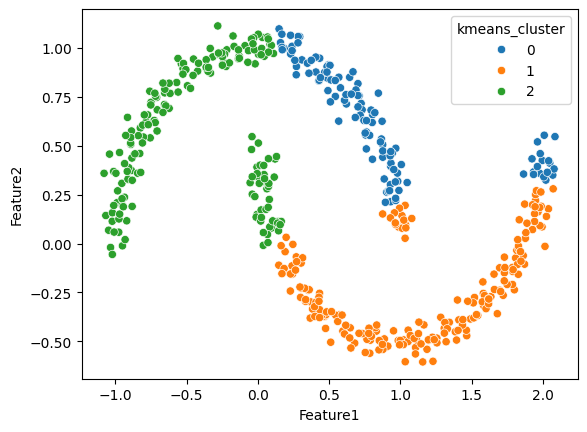

In [33]:
sns.scatterplot(x=df['Feature1'],
                y=df['Feature2'],
                hue=df['kmeans_cluster'],
                palette='tab10')

In [35]:
dbscan= DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [36]:
df['dbscan_cluster'] = dbscan_labels

<Axes: xlabel='Feature1', ylabel='Feature2'>

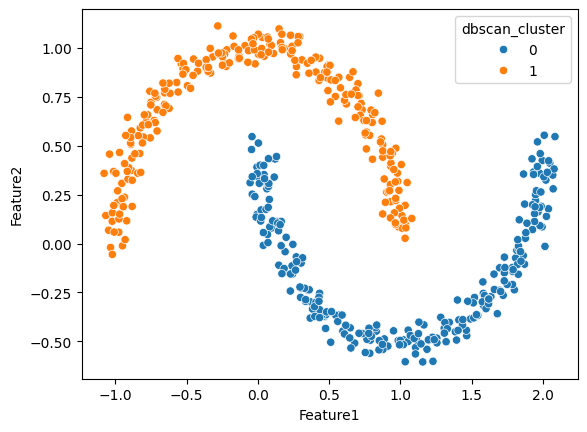

In [37]:
sns.scatterplot(x=df['Feature1'],
                y=df['Feature2'],
                hue=df['dbscan_cluster'],
                palette='tab10')